<div style="text-align:center; padding: 22px 28px 10px 28px; font-family: 'Segoe UI', sans-serif; color:#113A5C;">
  
  <div style="display:inline-block; padding: 10px 18px; border-radius: 999px; background: linear-gradient(90deg, #EAF2FB, #EEF8E7); font-size: 14px; letter-spacing: 0.08em; text-transform: uppercase; color:#004E9A; font-weight:600;">
    INFB8090 - Computacion Paralela
  </div>
  <h1 style="margin: 18px 0 8px 0; font-size: 34px; color:#004E9A;">Laboratorio 4: Diseno de algoritmos paralelos</h1>
  <p style="max-width: 920px; margin: 0 auto 16px auto; font-size: 16px; line-height: 1.65; color:#24435B;">
    Notebook de diseno algoritmico con casos originales sobre descomposicion, particionamiento, dependencias, halos, reduccion y pseudocodigo paralelo.
  </p>
  <div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:12px; max-width: 900px; margin: 20px auto 0 auto; text-align:left;">
    <div style="background:#FFFFFF; border:1px solid #D6E4F2; border-radius:18px; padding:16px 18px; box-shadow:0 10px 24px rgba(0,78,154,0.06);">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#6B7A88; margin-bottom:6px;">Integrantes</div>
      <div style="font-size:18px; font-weight:600; color:#113A5C;">Welinton Barrera<br/>Joaquin Araya</div>
    </div>
    <div style="background:#FFFFFF; border:1px solid #DCEBD0; border-radius:18px; padding:16px 18px; box-shadow:0 10px 24px rgba(122,184,48,0.08);">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#6B7A88; margin-bottom:6px;">Docencia</div>
      <div style="font-size:18px; font-weight:600; color:#113A5C;">Dr. Ing. Michael Miranda Sandoval<br/>Seccion 412</div>
    </div>
  </div>
  <div style="margin-top:18px; font-size:14px; color:#5B6B77;">
    Universidad Tecnologica Metropolitana | Primer semestre 2026 | Entrega: 30 de abril de 2026
  </div>
</div>

## Contexto y objetivo

Este notebook fue construido para **no repetir los ejemplos del PDF**, pero si responder exactamente a los aprendizajes del Laboratorio 4:

- analizar un problema antes de escoger una herramienta concurrente;
- distinguir descomposicion por datos, reduccion, particionamiento y dependencias locales;
- redactar pseudocodigo paralelo con asignacion, trabajo local, coordinacion y combinacion final;
- justificar granularidad, balance de carga, locality, overhead y puntos de sincronizacion.

Los tres desafios se resuelven con escenarios propios:

1. sensores ambientales para comparar patron `map`, patron `reduction` y esquemas de particionamiento;
2. estadisticas de severidad y un indice de salto termico con halos para mostrar reduccion y dependencia local;
3. pipeline de telemetria ambiental por lotes con asignacion balanceada y justificacion tecnica final.

In [1]:
import json
import math
import os
import platform
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, Markdown, display

sns.set_theme(style="whitegrid")
sns.set_palette(["#004E9A", "#7AB830", "#113A5C", "#3C91E6", "#A3D65C"])
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.facecolor"] = "#FAFCFE"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["grid.alpha"] = 0.18
plt.rcParams["font.family"] = "DejaVu Sans"

ROOT = Path.cwd()
SUMMARY_PATH = ROOT / "_lab4_summary.json"

try:
    import psutil
except ImportError:
    psutil = None


def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def fmt_float(value, digits=3):
    if value is None or pd.isna(value):
        return "-"
    return f"{value:.{digits}f}"


def fmt_ratio(value):
    return f"{value:.2f}x"


def callout(title, body, accent="#004E9A", bg="#F5F9FE"):
    display(
        HTML(
            f"""
            <div style="border-left:6px solid {accent}; background:{bg}; padding:14px 18px; margin:16px 0; border-radius:12px;">
              <div style="font-weight:700; color:#113A5C; margin-bottom:6px;">{escape(title)}</div>
              <div style="color:#304B5F; line-height:1.65;">{body}</div>
            </div>
            """
        )
    )


def metric_cards(items):
    cards = []
    for label, value, note, accent in items:
        cards.append(
            f"""
            <div style="background:white; border:1px solid #D8E4EF; border-top:5px solid {accent}; border-radius:16px; padding:14px 16px; box-shadow:0 10px 24px rgba(17,58,92,0.05);">
              <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#72808D; margin-bottom:8px;">{escape(label)}</div>
              <div style="font-size:28px; font-weight:700; color:#113A5C; margin-bottom:6px;">{escape(str(value))}</div>
              <div style="font-size:13px; color:#4C6273;">{note}</div>
            </div>
            """
        )
    display(
        HTML(
            "<div style='display:grid; grid-template-columns:repeat(auto-fit, minmax(220px, 1fr)); gap:14px; margin:10px 0 18px 0;'>"
            + "".join(cards)
            + "</div>"
        )
    )


def show_df(df, caption, formats=None, gradient_cols=None):
    styler = (
        df.style.hide(axis="index")
        .set_caption(caption)
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("text-align", "left"),
                        ("font-size", "1.05rem"),
                        ("font-weight", "700"),
                        ("color", "#113A5C"),
                        ("padding", "0 0 8px 0"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#004E9A"),
                        ("color", "white"),
                        ("padding", "8px 10px"),
                        ("border", "1px solid #D8E4EF"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "8px 10px"),
                        ("border", "1px solid #D8E4EF"),
                    ],
                },
            ]
        )
    )
    if formats:
        styler = styler.format(formats)
    if gradient_cols:
        styler = styler.background_gradient(subset=gradient_cols, cmap="Blues")
    display(styler)


def partition_blocks(n, p):
    base = n // p
    remainder = n % p
    blocks = []
    start = 0
    for worker in range(p):
        end = start + base + (1 if worker < remainder else 0)
        blocks.append((worker, start, end))
        start = end
    return blocks


def assign_blocks(n, p):
    assignments = {}
    for worker, start, end in partition_blocks(n, p):
        assignments[worker] = list(range(start, end))
    return assignments


def assign_cyclic(n, p):
    return {worker: list(range(worker, n, p)) for worker in range(p)}


def assign_adaptive_lpt(costs, p):
    assignments = {worker: [] for worker in range(p)}
    loads = {worker: 0.0 for worker in range(p)}
    for task_id in sorted(range(len(costs)), key=lambda idx: costs[idx], reverse=True):
        worker = min(loads, key=loads.get)
        assignments[worker].append(task_id)
        loads[worker] += float(costs[task_id])
    for worker in assignments:
        assignments[worker].sort()
    return assignments


def assignment_metrics(assignments, costs, name, locality):
    worker_loads = []
    for worker, task_ids in assignments.items():
        load = float(sum(costs[idx] for idx in task_ids))
        worker_loads.append({"Worker": worker, "Carga estimada": load, "Tareas": len(task_ids)})
    loads_df = pd.DataFrame(worker_loads)
    mean_load = loads_df["Carga estimada"].mean()
    max_load = loads_df["Carga estimada"].max()
    min_load = loads_df["Carga estimada"].min()
    return {
        "Esquema": name,
        "Carga minima": min_load,
        "Carga promedio": mean_load,
        "Carga maxima": max_load,
        "Desbalance max/prom": max_load / mean_load,
        "Rango max-min": max_load - min_load,
        "Locality esperada": locality,
    }, loads_df.assign(Esquema=name)


def to_json_records(df):
    return json.loads(df.to_json(orient="records"))

In [2]:
env_rows = [
    {"Campo": "Sistema operativo", "Valor": platform.platform()},
    {"Campo": "Version de Python", "Valor": platform.python_version()},
    {"Campo": "CPU logicos visibles", "Valor": os.cpu_count()},
    {"Campo": "RAM aproximada", "Valor": f"{psutil.virtual_memory().total / 1024**3:.2f} GB" if psutil else "No disponible"},
    {"Campo": "Librerias usadas", "Valor": "numpy, pandas, matplotlib, seaborn, nbformat, nbclient"},
    {"Campo": "Directorio de trabajo", "Valor": str(ROOT)},
]
env_df = pd.DataFrame(env_rows)
show_df(env_df, "Registro minimo del entorno")

callout(
    "Metodologia del laboratorio",
    "<ul style='margin:0; padding-left:18px;'>"
    "<li>Los casos son sinteticos y reproducibles para que los resultados puedan revisarse.</li>"
    "<li>El foco no es acelerar codigo, sino disenar correctamente la estrategia paralela.</li>"
    "<li>Cada desafio explicita entrada, salida, patron dominante, particionamiento, dependencias y coordinacion.</li>"
    "<li>La validacion en Python verifica equivalencia entre formulacion secuencial y formulacion por particiones.</li>"
    "</ul>",
    accent="#7AB830",
    bg="#F3FAEC",
)

Campo,Valor
Sistema operativo,Windows-11-10.0.26200-SP0
Version de Python,3.13.5
CPU logicos visibles,16
RAM aproximada,15.26 GB
Librerias usadas,"numpy, pandas, matplotlib, seaborn, nbformat, nbclient"
Directorio de trabajo,C:\Users\welin\Desktop\universidad\Paralela\lab4


## Desafio 1 - Analizar estructuralmente antes de paralelizar

El primer desafio se resuelve con dos problemas propios sobre sensores ambientales. La intencion es mirar la estructura antes de hablar de hilos, procesos o librerias: primero se identifica si el trabajo es local, si requiere reduccion, donde aparecen dependencias y que esquema de particionamiento tendria sentido.

In [3]:
structural_rows = [
    {
        "Caso": "Calibracion de sensores urbanos",
        "Entrada": "Vector de lecturas crudas, factor de calibracion y umbral por sensor",
        "Salida": "Vector de lecturas corregidas y etiqueta local de severidad",
        "Operacion principal": "Aplicar correccion y clasificar cada posicion",
        "Descomposicion": "Por datos",
        "Patron": "Map",
        "Dependencias": "No hay dependencia verdadera entre posiciones",
        "Coordinacion": "Ensamblaje ordenado del vector final",
    },
    {
        "Caso": "Resumen de alertas por cuadrante",
        "Entrada": "Vector de severidades ya calibradas",
        "Salida": "Conteo de alertas, promedio, varianza y maximo global",
        "Operacion principal": "Calcular estadisticas parciales y fusionarlas",
        "Descomposicion": "Por datos con reduccion",
        "Patron": "Reduction",
        "Dependencias": "La salida global depende de todos los parciales",
        "Coordinacion": "Reduccion final despues del trabajo local",
    },
]
structural_df = pd.DataFrame(structural_rows)
show_df(structural_df, "Desafio 1.a - Identificacion de descomposicion, patrones y dependencias")

dependency_rows = [
    {
        "Caso": "Calibracion",
        "Unidades paralelizables": "Indices/sensores independientes",
        "Dependencia verdadera": "No: salida_i depende solo de lectura_i, factor_i y umbral_i",
        "Anti-dependencia": "No relevante si la entrada se usa solo como lectura",
        "Output-dependencia": "Solo aparece si dos workers escriben el mismo indice de salida",
        "Parte secuencial o coordinada": "Ensamblaje ordenado del vector final",
        "Control propuesto": "Asignar indices disjuntos y no modificar la entrada",
    },
    {
        "Caso": "Resumen",
        "Unidades paralelizables": "Chunks del vector de severidad",
        "Dependencia verdadera": "Si: las estadisticas globales dependen de todos los parciales",
        "Anti-dependencia": "No relevante si cada worker lee el arreglo y escribe solo su parcial",
        "Output-dependencia": "Riesgo si varios workers actualizan un acumulador global compartido",
        "Parte secuencial o coordinada": "Reduccion final despues de una barrera logica",
        "Control propuesto": "Usar acumuladores locales y reducir parciales",
    },
]
dependency_df = pd.DataFrame(dependency_rows)
show_df(dependency_df, "Dependencias explicitas y unidades paralelizables")

metric_cards(
    [
        ("Problemas analizados", "2", "Uno tipo map y otro tipo reduction", "#004E9A"),
        ("Decision clave", "Partir por datos", "Los arreglos permiten rangos disjuntos", "#7AB830"),
        ("Coordinacion real", "Solo al combinar", "En map es ensamblaje; en reduction es fusion global", "#113A5C"),
    ]
)

Caso,Entrada,Salida,Operacion principal,Descomposicion,Patron,Dependencias,Coordinacion
Calibracion de sensores urbanos,"Vector de lecturas crudas, factor de calibracion y umbral por sensor",Vector de lecturas corregidas y etiqueta local de severidad,Aplicar correccion y clasificar cada posicion,Por datos,Map,No hay dependencia verdadera entre posiciones,Ensamblaje ordenado del vector final
Resumen de alertas por cuadrante,Vector de severidades ya calibradas,"Conteo de alertas, promedio, varianza y maximo global",Calcular estadisticas parciales y fusionarlas,Por datos con reduccion,Reduction,La salida global depende de todos los parciales,Reduccion final despues del trabajo local


Caso,Unidades paralelizables,Dependencia verdadera,Anti-dependencia,Output-dependencia,Parte secuencial o coordinada,Control propuesto
Calibracion,Indices/sensores independientes,"No: salida_i depende solo de lectura_i, factor_i y umbral_i",No relevante si la entrada se usa solo como lectura,Solo aparece si dos workers escriben el mismo indice de salida,Ensamblaje ordenado del vector final,Asignar indices disjuntos y no modificar la entrada
Resumen,Chunks del vector de severidad,Si: las estadisticas globales dependen de todos los parciales,No relevante si cada worker lee el arreglo y escribe solo su parcial,Riesgo si varios workers actualizan un acumulador global compartido,Reduccion final despues de una barrera logica,Usar acumuladores locales y reducir parciales


### 1.b - Comparacion entre esquemas de particionamiento

Para no usar el ejemplo del PDF, se construye un dominio irregular de sensores. Algunos sensores tienen costo extra por validacion historica, otros por estar sobre umbral y otros por requerir correccion extendida. El objetivo es comparar tres formas de repartir la misma carga: bloques contiguos, esquema ciclico y asignacion adaptada por costo estimado.

Esquema,Carga minima,Carga promedio,Carga maxima,Desbalance max/prom,Rango max-min,Locality esperada
Bloques contiguos,54.0,64.5,90.0,1.395,36.0,Alta
Ciclico,60.5,64.5,72.5,1.124,12.0,Media-baja
Adaptado por costo,64.0,64.5,65.0,1.008,1.0,Baja


Worker,Carga estimada,Tareas,Esquema
0,90.0,24,Bloques contiguos
1,57.0,24,Bloques contiguos
2,54.0,24,Bloques contiguos
3,57.0,24,Bloques contiguos
0,60.5,24,Ciclico
1,63.5,24,Ciclico
2,61.5,24,Ciclico
3,72.5,24,Ciclico
0,65.0,24,Adaptado por costo
1,64.5,25,Adaptado por costo


Esquema,Balance de carga,Locality,Overhead de coordinacion,Si el costo no es uniforme,Recomendacion tecnica
Bloques contiguos,Bueno si el costo por dato es regular; debil si hay zonas pesadas juntas,"Alta, porque cada worker recorre indices contiguos",Bajo: basta calcular rangos inicio-fin,Puede concentrar trabajo caro en pocos workers,Usarlo cuando importa locality y la carga es bastante regular
Ciclico,Mejor que bloques si los costos pesados estan distribuidos periodicamente,"Media-baja, porque cada worker salta entre indices",Medio: asignacion simple pero con accesos dispersos,"Reduce concentracion de costo, pero no estima carga real",Usarlo como alternativa simple ante irregularidad moderada
Adaptado por costo,El mejor en este caso porque usa una estimacion de costo,"Baja, porque mezcla indices alejados",Mayor: requiere estimar costos y planificar asignacion,Responde mejor mientras la estimacion sea razonable,Usarlo cuando el desbalance sea mas caro que perder locality


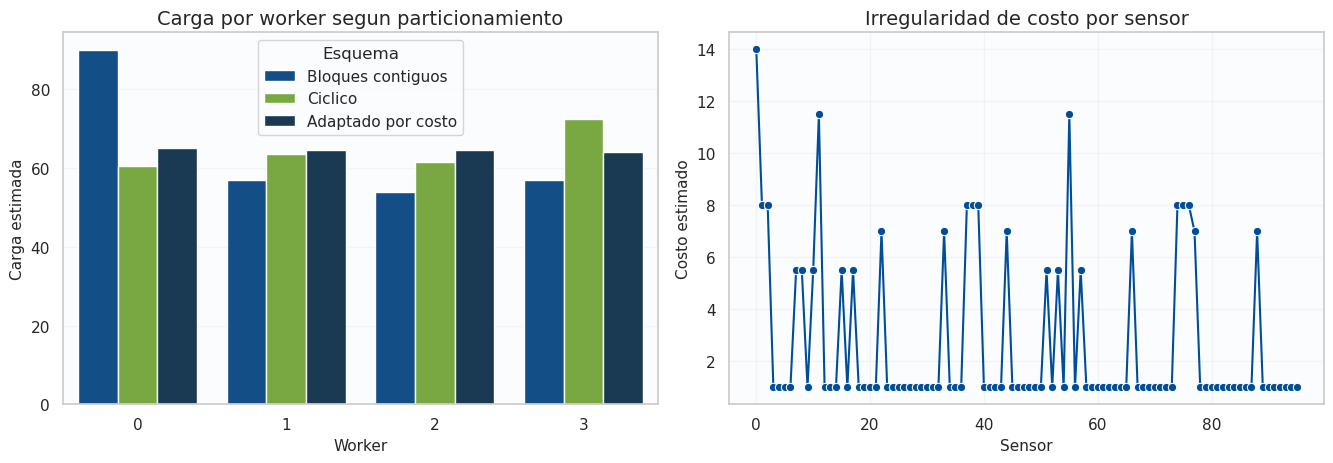

In [4]:
sensor_count = 96
workers = 4
sensor_id = np.arange(sensor_count)
rng = np.random.default_rng(41204)
raw_signal = 0.45 + 0.35 * np.sin(sensor_id / 7.0) + rng.normal(0.0, 0.07, sensor_count)
raw_signal = np.clip(raw_signal, 0, 1.15)

estimated_cost = (
    1.0
    + np.where(sensor_id % 11 == 0, 6.0, 0.0)
    + np.where(raw_signal > 0.78, 4.5, 0.0)
    + np.where(np.isin(sensor_id % 37, [0, 1, 2]), 7.0, 0.0)
)

partition_schemes = [
    ("Bloques contiguos", assign_blocks(sensor_count, workers), "Alta"),
    ("Ciclico", assign_cyclic(sensor_count, workers), "Media-baja"),
    ("Adaptado por costo", assign_adaptive_lpt(estimated_cost, workers), "Baja"),
]

metric_rows = []
load_tables = []
for name, assignments, locality in partition_schemes:
    metrics, loads = assignment_metrics(assignments, estimated_cost, name, locality)
    metric_rows.append(metrics)
    load_tables.append(loads)

partition_metrics_df = pd.DataFrame(metric_rows)
show_df(
    partition_metrics_df,
    "Desafio 1.b - Comparacion de particionamiento sobre carga irregular",
    formats={
        "Carga minima": "{:.1f}",
        "Carga promedio": "{:.1f}",
        "Carga maxima": "{:.1f}",
        "Desbalance max/prom": "{:.3f}",
        "Rango max-min": "{:.1f}",
    },
    gradient_cols=["Desbalance max/prom", "Rango max-min"],
)

worker_loads_df = pd.concat(load_tables, ignore_index=True)
show_df(
    worker_loads_df,
    "Carga estimada por worker para cada esquema",
    formats={"Worker": "{:.0f}", "Carga estimada": "{:.1f}", "Tareas": "{:.0f}"},
    gradient_cols=["Carga estimada"],
)

partition_tradeoff_df = pd.DataFrame(
    [
        {
            "Esquema": "Bloques contiguos",
            "Balance de carga": "Bueno si el costo por dato es regular; debil si hay zonas pesadas juntas",
            "Locality": "Alta, porque cada worker recorre indices contiguos",
            "Overhead de coordinacion": "Bajo: basta calcular rangos inicio-fin",
            "Si el costo no es uniforme": "Puede concentrar trabajo caro en pocos workers",
            "Recomendacion tecnica": "Usarlo cuando importa locality y la carga es bastante regular",
        },
        {
            "Esquema": "Ciclico",
            "Balance de carga": "Mejor que bloques si los costos pesados estan distribuidos periodicamente",
            "Locality": "Media-baja, porque cada worker salta entre indices",
            "Overhead de coordinacion": "Medio: asignacion simple pero con accesos dispersos",
            "Si el costo no es uniforme": "Reduce concentracion de costo, pero no estima carga real",
            "Recomendacion tecnica": "Usarlo como alternativa simple ante irregularidad moderada",
        },
        {
            "Esquema": "Adaptado por costo",
            "Balance de carga": "El mejor en este caso porque usa una estimacion de costo",
            "Locality": "Baja, porque mezcla indices alejados",
            "Overhead de coordinacion": "Mayor: requiere estimar costos y planificar asignacion",
            "Si el costo no es uniforme": "Responde mejor mientras la estimacion sea razonable",
            "Recomendacion tecnica": "Usarlo cuando el desbalance sea mas caro que perder locality",
        },
    ]
)
show_df(partition_tradeoff_df, "Trade-offs cualitativos de particionamiento")

best_partition = partition_metrics_df.loc[partition_metrics_df["Desbalance max/prom"].idxmin()]

metric_cards(
    [
        (
            "Mejor balance",
            best_partition["Esquema"],
            f"Desbalance max/prom: {best_partition['Desbalance max/prom']:.3f}",
            "#004E9A",
        ),
        (
            "Mejor locality",
            "Bloques contiguos",
            "Acceso secuencial a memoria y menor salto entre indices",
            "#7AB830",
        ),
        (
            "Trade-off central",
            "Balance vs locality",
            "La asignacion mas balanceada puede perder acceso contiguo",
            "#113A5C",
        ),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
sns.barplot(data=worker_loads_df, x="Worker", y="Carga estimada", hue="Esquema", ax=axes[0])
axes[0].set_title("Carga por worker segun particionamiento")
axes[0].set_ylabel("Carga estimada")
axes[0].set_xlabel("Worker")

sensor_cost_df = pd.DataFrame({"Sensor": sensor_id, "Costo estimado": estimated_cost, "Lectura": raw_signal})
sns.lineplot(data=sensor_cost_df, x="Sensor", y="Costo estimado", marker="o", ax=axes[1], color="#004E9A")
axes[1].set_title("Irregularidad de costo por sensor")
axes[1].set_ylabel("Costo estimado")
axes[1].set_xlabel("Sensor")

plt.tight_layout()
plt.show()

In [5]:
display(
    Markdown(
        f"""
        ### Interpretacion del desafio 1

        La calibracion de sensores se comporta como un patron **map**: cada salida depende solo de la entrada del mismo indice,
        por lo que basta asignar rangos disjuntos para evitar escrituras repetidas. En cambio, el resumen de alertas se comporta
        como una **reduction**: cada worker puede calcular parciales, pero el resultado global solo existe despues de combinar
        esos parciales.

        En el caso de particionamiento, el mejor balance observado fue **{best_partition['Esquema']}**, con desbalance
        maximo/promedio de **{best_partition['Desbalance max/prom']:.3f}x**. Sin embargo, esa opcion no es por si sola
        la mejor en todos los escenarios. Los bloques contiguos favorecen locality porque cada worker recorre memoria cercana,
        mientras que la asignacion adaptada por costo reparte mejor una carga irregular al precio de mayor overhead de planificacion
        y menor contiguidad.

        La conclusion tecnica es que particionar no significa solamente dividir en partes iguales. La decision debe considerar
        costo por dato, regularidad, locality, overhead y necesidad de coordinacion.
        """
    )
)


        ### Interpretacion del desafio 1

        La calibracion de sensores se comporta como un patron **map**: cada salida depende solo de la entrada del mismo indice,
        por lo que basta asignar rangos disjuntos para evitar escrituras repetidas. En cambio, el resumen de alertas se comporta
        como una **reduction**: cada worker puede calcular parciales, pero el resultado global solo existe despues de combinar
        esos parciales.

        En el caso de particionamiento, el mejor balance observado fue **Adaptado por costo**, con desbalance
        maximo/promedio de **1.008x**. Sin embargo, esa opcion no es por si sola
        la mejor en todos los escenarios. Los bloques contiguos favorecen locality porque cada worker recorre memoria cercana,
        mientras que la asignacion adaptada por costo reparte mejor una carga irregular al precio de mayor overhead de planificacion
        y menor contiguidad.

        La conclusion tecnica es que particionar no significa solamente dividir en partes iguales. La decision debe considerar
        costo por dato, regularidad, locality, overhead y necesidad de coordinacion.
        

## Desafio 2 - Del problema al pseudocodigo paralelo

Este desafio transforma el analisis anterior en pseudocodigo ejecutable conceptualmente. Primero se diseña una reduccion por chunks para estadisticas de severidad. Luego se diseña un caso con dependencia local, donde una particion ingenua no basta porque cada posicion necesita vecinos de otras particiones.

### 2.a - Caso de arreglo independiente con reduccion

**Problema propuesto:** dada una serie grande de severidades ambientales, calcular promedio, varianza y maximo global. Cada worker recibe un chunk, calcula estadisticas parciales y luego una etapa global reduce los parciales.

```text
PSEUDOCODIGO SECUENCIAL
entrada: severidad[0..n-1]
suma = 0
suma2 = 0
maximo = -infinito
para i desde 0 hasta n-1:
    suma = suma + severidad[i]
    suma2 = suma2 + severidad[i] * severidad[i]
    maximo = max(maximo, severidad[i])
promedio = suma / n
varianza = (suma2 / n) - promedio * promedio
salida: promedio, varianza, maximo
```

```text
PSEUDOCODIGO PARALELO
entrada: severidad[0..n-1], workers p
tramos = particionar_en_bloques(n, p)
paralelo para cada worker w:
    inicio, fin = tramos[w]
    n_local = 0
    suma_local = 0
    suma2_local = 0
    max_local = -infinito
    para i desde inicio hasta fin-1:
        n_local = n_local + 1
        suma_local = suma_local + severidad[i]
        suma2_local = suma2_local + severidad[i] * severidad[i]
        max_local = max(max_local, severidad[i])
    emitir parcial(w, n_local, suma_local, suma2_local, max_local)
barrera logica
n_total = suma de n_local
suma_total = suma de suma_local
suma2_total = suma de suma2_local
max_global = maximo de max_local
promedio = suma_total / n_total
varianza = (suma2_total / n_total) - promedio * promedio
salida: promedio, varianza, max_global
```

In [6]:
rng = np.random.default_rng(80904)
n_measurements = 120_000
temperatura = rng.normal(loc=21.0, scale=4.0, size=n_measurements)
humedad = rng.uniform(30.0, 86.0, size=n_measurements)
pm25 = rng.gamma(shape=2.4, scale=6.5, size=n_measurements)
severity = (
    0.45 * pm25
    + 1.80 * np.maximum(temperatura - 28.0, 0.0)
    + 0.08 * np.maximum(humedad - 70.0, 0.0)
)


def sequential_severity_stats(values):
    n = int(values.size)
    total = float(values.sum())
    total2 = float(np.square(values).sum())
    max_value = float(values.max())
    mean = total / n
    variance = (total2 / n) - mean * mean
    return {"n": n, "suma": total, "suma2": total2, "promedio": mean, "varianza": variance, "maximo": max_value}


def partial_severity_stats(values, start, end, worker):
    chunk = values[start:end]
    n_local = int(chunk.size)
    sum_local = float(chunk.sum())
    sum2_local = float(np.square(chunk).sum())
    max_local = float(chunk.max())
    return {
        "Worker": worker,
        "Inicio": start,
        "Fin": end,
        "n_local": n_local,
        "suma_local": sum_local,
        "suma2_local": sum2_local,
        "max_local": max_local,
    }


def reduce_severity_partials(partials):
    n_total = int(sum(item["n_local"] for item in partials))
    sum_total = float(sum(item["suma_local"] for item in partials))
    sum2_total = float(sum(item["suma2_local"] for item in partials))
    max_global = float(max(item["max_local"] for item in partials))
    mean = sum_total / n_total
    variance = (sum2_total / n_total) - mean * mean
    return {"n": n_total, "suma": sum_total, "suma2": sum2_total, "promedio": mean, "varianza": variance, "maximo": max_global}


reduction_workers = 8
seq_stats = sequential_severity_stats(severity)
partials = [
    partial_severity_stats(severity, start, end, worker)
    for worker, start, end in partition_blocks(n_measurements, reduction_workers)
]
parallel_stats = reduce_severity_partials(partials)

for key in ["n", "suma", "suma2", "promedio", "varianza", "maximo"]:
    assert np.isclose(seq_stats[key], parallel_stats[key])

partials_df = pd.DataFrame(partials)
show_df(
    partials_df[["Worker", "Inicio", "Fin", "n_local", "suma_local", "max_local"]],
    "Parciales calculados por chunk",
    formats={
        "Worker": "{:.0f}",
        "Inicio": fmt_int,
        "Fin": fmt_int,
        "n_local": fmt_int,
        "suma_local": "{:.2f}",
        "max_local": "{:.3f}",
    },
    gradient_cols=["suma_local", "max_local"],
)

comparison_rows = []
for metric in ["promedio", "varianza", "maximo"]:
    comparison_rows.append(
        {
            "Metrica": metric,
            "Secuencial": seq_stats[metric],
            "Por particiones": parallel_stats[metric],
            "Diferencia absoluta": abs(seq_stats[metric] - parallel_stats[metric]),
        }
    )
reduction_compare_df = pd.DataFrame(comparison_rows)
show_df(
    reduction_compare_df,
    "Validacion de equivalencia: reduccion secuencial vs por chunks",
    formats={"Secuencial": "{:.8f}", "Por particiones": "{:.8f}", "Diferencia absoluta": "{:.2e}"},
    gradient_cols=["Diferencia absoluta"],
)

reduction_max_error = float(reduction_compare_df["Diferencia absoluta"].max())
metric_cards(
    [
        ("Workers conceptuales", reduction_workers, "Chunks contiguos de igual tamano", "#004E9A"),
        ("Error maximo", f"{reduction_max_error:.2e}", "Diferencia numerica por orden de suma", "#7AB830"),
        ("Sincronizacion", "1 barrera", "Antes de reducir parciales globales", "#113A5C"),
    ]
)

Worker,Inicio,Fin,n_local,suma_local,max_local
0,0,15.000,15.000,110047.92,48.010
1,15.000,30.000,15.000,109716.60,38.435
2,30.000,45.000,15.000,109600.69,40.299
3,45.000,60.000,15.000,110327.92,44.839
4,60.000,75.000,15.000,109318.84,39.734
5,75.000,90.000,15.000,109500.92,34.475
6,90.000,105.000,15.000,110609.59,41.130
7,105.000,120.000,15.000,109344.64,35.715


Metrica,Secuencial,Por particiones,Diferencia absoluta
promedio,7.32055938,7.32055938,0.00e+00
varianza,21.31050635,21.31050635,0.00e+00
maximo,48.00988090,48.00988090,0.00e+00


In [7]:
variables_reduction_df = pd.DataFrame(
    [
        {
            "Tipo": "Locales por worker",
            "Variables": "n_local, suma_local, suma2_local, max_local",
            "Motivo": "Evitan escrituras concurrentes sobre acumuladores compartidos",
        },
        {
            "Tipo": "Globales de reduccion",
            "Variables": "n_total, suma_total, suma2_total, max_global",
            "Motivo": "Se calculan despues de recibir todos los parciales",
        },
        {
            "Tipo": "Punto de coordinacion",
            "Variables": "barrera logica antes de combinar",
            "Motivo": "La reduccion global no es correcta si faltan parciales",
        },
    ]
)
show_df(variables_reduction_df, "Variables y coordinacion del diseno de reduccion")

display(
    Markdown(
        f"""
        ### Interpretacion del desafio 2.a

        Este problema es paralelizable por datos porque cada chunk puede calcular sus parciales sin escribir en variables globales.
        La parte no paralela aparece al final: la reduccion debe esperar todos los parciales para calcular promedio, varianza y maximo.
        Por eso el diseno usa variables locales por worker y solo combina despues de una barrera logica.

        La validacion confirma que la estrategia conserva la correctitud: la diferencia maxima observada entre el calculo secuencial
        y el calculo por particiones fue **{reduction_max_error:.2e}**. La pequena diferencia posible se explica por el orden de suma
        en punto flotante, no por un cambio en la definicion del algoritmo.
        """
    )
)

Tipo,Variables,Motivo
Locales por worker,"n_local, suma_local, suma2_local, max_local",Evitan escrituras concurrentes sobre acumuladores compartidos
Globales de reduccion,"n_total, suma_total, suma2_total, max_global",Se calculan despues de recibir todos los parciales
Punto de coordinacion,barrera logica antes de combinar,La reduccion global no es correcta si faltan parciales



        ### Interpretacion del desafio 2.a

        Este problema es paralelizable por datos porque cada chunk puede calcular sus parciales sin escribir en variables globales.
        La parte no paralela aparece al final: la reduccion debe esperar todos los parciales para calcular promedio, varianza y maximo.
        Por eso el diseno usa variables locales por worker y solo combina despues de una barrera logica.

        La validacion confirma que la estrategia conserva la correctitud: la diferencia maxima observada entre el calculo secuencial
        y el calculo por particiones fue **0.00e+00**. La pequena diferencia posible se explica por el orden de suma
        en punto flotante, no por un cambio en la definicion del algoritmo.
        

### 2.b - Caso con dependencia local y frontera

**Problema propuesto:** calcular un indice de salto termico sobre una serie temporal. Para cada posicion interna se usan dos vecinos a la izquierda y dos vecinos a la derecha. Esto fuerza a pensar en fronteras entre particiones.

```text
PSEUDOCODIGO SECUENCIAL
entrada: temp[0..n-1], halo = 2
salida: salto[0..n-1] inicializado como indefinido
para i desde halo hasta n-halo-1:
    ventana = temp[i-2..i+2]
    tendencia = temp[i+2] - temp[i-2]
    variacion_local = abs(temp[i] - promedio(ventana))
    salto[i] = tendencia + 0.5 * variacion_local
salida: salto
```

```text
PSEUDOCODIGO PARALELO CON HALOS
entrada: temp[0..n-1], workers p, halo = 2
tramos = particionar_en_bloques(n, p)
paralelo para cada worker w:
    inicio, fin = tramos[w]
    lectura_inicio = max(0, inicio - halo)
    lectura_fin = min(n, fin + halo)
    temp_local = temp[lectura_inicio..lectura_fin-1]
    salida_local = []
    para i global desde max(inicio, halo) hasta min(fin, n-halo)-1:
        calcular salto[i] usando temp[i-2..i+2]
        agregar (i, salto[i]) a salida_local
    emitir salida_local
barrera logica
ensamblar cada salida_local en el arreglo final
salida: salto
```

Worker,Tramo propio,Rango leido con halo,Salida escrita,Celdas extra leidas
0,"[0, 45)","[0, 47)","[2, 45)",2
1,"[45, 90)","[43, 92)","[45, 90)",4
2,"[90, 135)","[88, 137)","[90, 135)",4
3,"[135, 180)","[133, 180)","[135, 178)",2


Version,Valores validos,Valores faltantes internos,Error vs secuencial
Secuencial,176,0,0.00e+00
Paralela con halo,176,0,0.00e+00
Particion ingenua sin halo,164,12,-


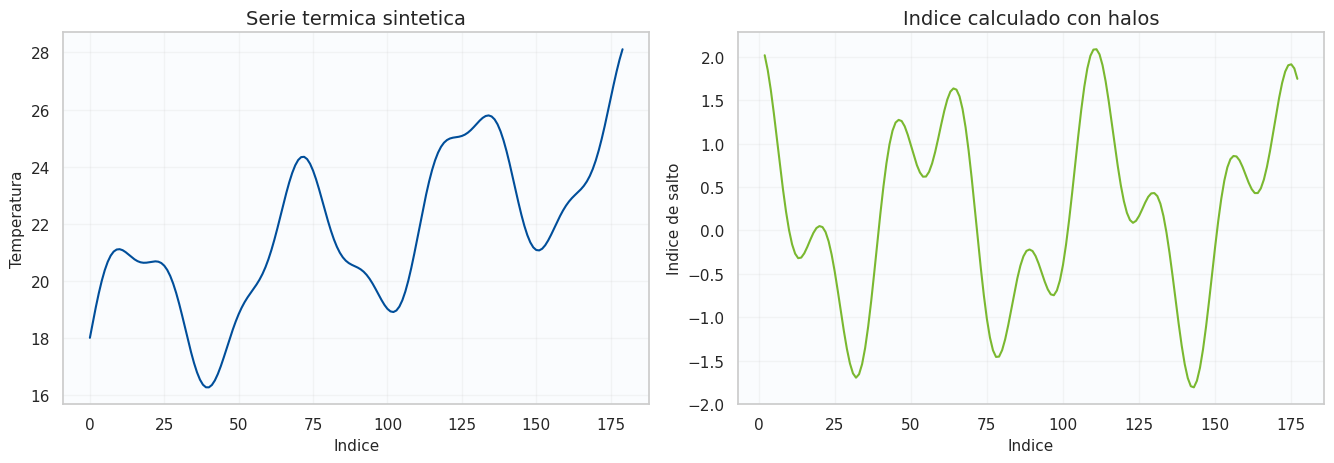

In [8]:
series_n = 180
halo = 2
t = np.arange(series_n)
temp_series = 18 + 0.04 * t + 2.8 * np.sin(t / 9.0) + 0.7 * np.sin(t / 3.5)


def thermal_jump_sequential(series, halo=2):
    out = np.full(series.shape, np.nan, dtype=float)
    for i in range(halo, len(series) - halo):
        window = series[i - halo : i + halo + 1]
        trend = series[i + halo] - series[i - halo]
        local_variation = abs(series[i] - float(window.mean()))
        out[i] = trend + 0.5 * local_variation
    return out


def thermal_jump_partitioned_with_halo(series, p, halo=2):
    out = np.full(series.shape, np.nan, dtype=float)
    metadata = []
    for worker, start, end in partition_blocks(len(series), p):
        read_start = max(0, start - halo)
        read_end = min(len(series), end + halo)
        valid_start = max(start, halo)
        valid_end = min(end, len(series) - halo)
        for i in range(valid_start, valid_end):
            window = series[i - halo : i + halo + 1]
            trend = series[i + halo] - series[i - halo]
            local_variation = abs(series[i] - float(window.mean()))
            out[i] = trend + 0.5 * local_variation
        metadata.append(
            {
                "Worker": worker,
                "Tramo propio": f"[{start}, {end})",
                "Rango leido con halo": f"[{read_start}, {read_end})",
                "Salida escrita": f"[{valid_start}, {valid_end})",
                "Celdas extra leidas": (read_end - read_start) - (end - start),
            }
        )
    return out, pd.DataFrame(metadata)


def thermal_jump_naive_without_halo(series, p, halo=2):
    out = np.full(series.shape, np.nan, dtype=float)
    for worker, start, end in partition_blocks(len(series), p):
        valid_start = start + halo
        valid_end = end - halo
        if valid_start >= valid_end:
            continue
        for i in range(valid_start, valid_end):
            window = series[i - halo : i + halo + 1]
            trend = series[i + halo] - series[i - halo]
            local_variation = abs(series[i] - float(window.mean()))
            out[i] = trend + 0.5 * local_variation
    return out


stencil_workers = 4
stencil_seq = thermal_jump_sequential(temp_series, halo=halo)
stencil_parallel, halo_df = thermal_jump_partitioned_with_halo(temp_series, stencil_workers, halo=halo)
stencil_naive = thermal_jump_naive_without_halo(temp_series, stencil_workers, halo=halo)

valid_mask = ~np.isnan(stencil_seq)
stencil_max_error = float(np.nanmax(np.abs(stencil_seq[valid_mask] - stencil_parallel[valid_mask])))
missing_naive = int(np.sum(valid_mask & np.isnan(stencil_naive)))
assert np.allclose(stencil_seq[valid_mask], stencil_parallel[valid_mask], equal_nan=True)

show_df(
    halo_df,
    "Manejo de halos por particion",
    formats={"Worker": "{:.0f}", "Celdas extra leidas": "{:.0f}"},
)

stencil_compare_df = pd.DataFrame(
    [
        {
            "Version": "Secuencial",
            "Valores validos": int(np.sum(~np.isnan(stencil_seq))),
            "Valores faltantes internos": 0,
            "Error vs secuencial": 0.0,
        },
        {
            "Version": "Paralela con halo",
            "Valores validos": int(np.sum(~np.isnan(stencil_parallel))),
            "Valores faltantes internos": int(np.sum(valid_mask & np.isnan(stencil_parallel))),
            "Error vs secuencial": stencil_max_error,
        },
        {
            "Version": "Particion ingenua sin halo",
            "Valores validos": int(np.sum(~np.isnan(stencil_naive))),
            "Valores faltantes internos": missing_naive,
            "Error vs secuencial": np.nan,
        },
    ]
)
show_df(
    stencil_compare_df,
    "Validacion del caso con dependencia local",
    formats={
        "Valores validos": "{:.0f}",
        "Valores faltantes internos": "{:.0f}",
        "Error vs secuencial": lambda value: "-" if pd.isna(value) else f"{value:.2e}",
    },
    gradient_cols=["Valores faltantes internos"],
)

metric_cards(
    [
        ("Ancho de halo", halo, "Cada indice necesita dos vecinos por lado", "#004E9A"),
        ("Error con halo", f"{stencil_max_error:.2e}", "La particion reproduce la salida secuencial", "#7AB830"),
        ("Fallas sin halo", missing_naive, "Celdas internas quedan incompletas en fronteras", "#113A5C"),
    ]
)

sample_df = pd.DataFrame(
    {
        "Indice": t,
        "Temperatura": temp_series,
        "Salto termico": stencil_parallel,
    }
)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
sns.lineplot(data=sample_df, x="Indice", y="Temperatura", ax=axes[0], color="#004E9A")
axes[0].set_title("Serie termica sintetica")
axes[0].set_ylabel("Temperatura")
axes[0].set_xlabel("Indice")

sns.lineplot(data=sample_df, x="Indice", y="Salto termico", ax=axes[1], color="#7AB830")
axes[1].set_title("Indice calculado con halos")
axes[1].set_ylabel("Indice de salto")
axes[1].set_xlabel("Indice")

plt.tight_layout()
plt.show()

In [9]:
display(
    Markdown(
        f"""
        ### Interpretacion del desafio 2.b

        Este caso no es embarrassingly parallel, porque cada posicion interna depende de vecinos cercanos. Una particion por bloques
        sigue siendo posible, pero cada worker necesita leer un **halo de ancho {halo}** alrededor de su tramo. Si el worker solo
        recibiera sus indices propios, no podria calcular correctamente las posiciones cercanas a las fronteras.

        La validacion muestra que la version con halos coincide con la secuencial, con error maximo **{stencil_max_error:.2e}**.
        En cambio, la particion ingenua sin halo deja **{missing_naive}** posiciones internas sin calcular. Por eso el pseudocodigo
        paralelo debe explicitar tres cosas: rango propio, rango leido y rango escrito. Esa separacion evita duplicar escrituras y
        mantiene la correctitud.
        """
    )
)


        ### Interpretacion del desafio 2.b

        Este caso no es embarrassingly parallel, porque cada posicion interna depende de vecinos cercanos. Una particion por bloques
        sigue siendo posible, pero cada worker necesita leer un **halo de ancho 2** alrededor de su tramo. Si el worker solo
        recibiera sus indices propios, no podria calcular correctamente las posiciones cercanas a las fronteras.

        La validacion muestra que la version con halos coincide con la secuencial, con error maximo **0.00e+00**.
        En cambio, la particion ingenua sin halo deja **12** posiciones internas sin calcular. Por eso el pseudocodigo
        paralelo debe explicitar tres cosas: rango propio, rango leido y rango escrito. Esa separacion evita duplicar escrituras y
        mantiene la correctitud.
        

## Desafio 3 - Diseno integrador de una estrategia paralela

Para el desafio integrador se elige la opcion de **pipeline simple**. El problema propuesto es procesar lotes de telemetria ambiental: leer y validar cada lote, calibrar sus registros, calcular parciales locales y consolidar un resumen global.

### 3.a - Pipeline de lotes de telemetria ambiental

```text
ENTRADA
lotes[0..m-1], cada lote contiene registros de sensores, porcentaje de datos faltantes y zona urbana

SALIDA
resumen_global con conteo de registros validos, promedio de severidad, maximo global y alertas por zona

PSEUDOCODIGO PARALELO DEL PIPELINE
estimar costo_lote para cada lote usando cantidad de filas y porcentaje de datos faltantes
asignaciones = balancear_lotes_por_costo(lotes, workers)

paralelo para cada worker w:
    para cada lote en asignaciones[w]:
        registros = leer_lote(lote)
        registros_validos = validar(registros)
        registros_calibrados = calibrar(registros_validos)
        parcial = calcular_parcial(registros_calibrados)
        emitir parcial

barrera logica
resumen_global = reducir_todos_los_parciales(parciales)
salida resumen_global
```

Este pipeline mantiene las operaciones pesadas como trabajo local por lote. La coordinacion se concentra al final, donde se combinan parciales pequenos en vez de transferir todos los registros crudos.

Lote,Zona,Filas,Datos faltantes,Costo estimado
0,Norte,4.500,1.5%,7202.5
1,Centro,6.779,8.5%,8507.6
2,Sur,9.058,4.5%,10280.8
3,Poniente,11.337,11.5%,15248.3
4,Oriente,13.616,7.5%,16679.6
5,Norte,4.895,3.5%,5409.0
6,Centro,7.174,10.5%,11933.8
7,Sur,9.453,6.5%,11296.3
8,Poniente,11.732,2.5%,12611.9
9,Oriente,14.011,9.5%,18004.1


Worker,Lote,Zona,Filas,Costo estimado
0,1,Centro,6.779,8507.6
0,8,Poniente,11.732,12611.9
0,14,Oriente,14.406,19376.1
0,16,Centro,7.964,8800.2
1,0,Norte,4.500,7202.5
1,2,Sur,9.058,10280.8
1,9,Oriente,14.011,18004.1
1,10,Norte,5.290,6162.9
1,17,Sur,10.243,13469.5
2,4,Oriente,13.616,16679.6


Worker,Lotes asignados,Filas totales,Costo estimado
0,4,40.881,49295.8
1,5,43.102,55119.9
2,4,42.765,49649.7
3,5,38.939,54414.4


Etapa,Trabajo local,Coordinacion,Riesgo
Lectura y validacion,"Leer lote, descartar registros incompletos y marcar calidad",Ninguna entre lotes,Lotes con muchos faltantes consumen mas validacion
Calibracion,Aplicar factores por sensor y zona,Solo compartir parametros de calibracion de lectura,Transferir registros completos seria caro
Parciales locales,"Calcular conteos, sumas, suma de cuadrados y maximos por lote",Emitir parcial pequeno,Parciales mal definidos obligan a recalcular
Reduccion global,Fusionar parciales,Barrera logica final,Cuello secuencial si hay demasiados parciales pequenos


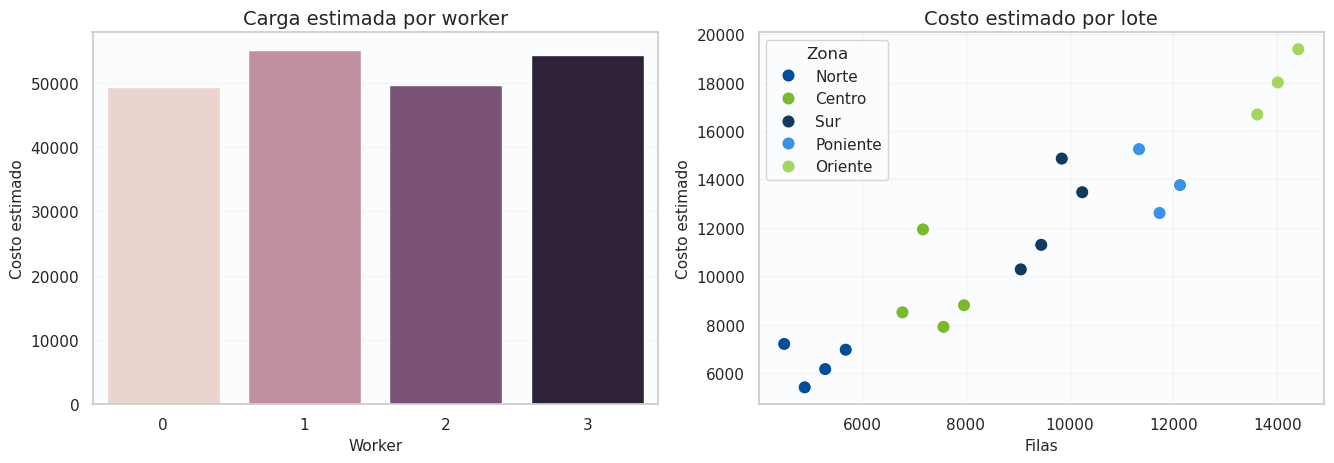

In [ ]:
batch_count = 18
pipeline_workers = 4
batch_ids = np.arange(batch_count)
rows = 4_500 + ((batch_ids * 1_379) % 6_500) + (batch_ids % 5) * 900
missing_pct = 0.015 + ((batch_ids * 7) % 11) / 100.0
zone = np.array(["Norte", "Centro", "Sur", "Poniente", "Oriente"])[batch_ids % 5]
estimated_batch_cost = rows * (1.0 + missing_pct * 3.0) + np.where(batch_ids % 6 == 0, 2_500, 0)

batch_df = pd.DataFrame(
    {
        "Lote": batch_ids,
        "Zona": zone,
        "Filas": rows,
        "Datos faltantes": missing_pct,
        "Costo estimado": estimated_batch_cost,
    }
)

assignments = assign_adaptive_lpt(estimated_batch_cost, pipeline_workers)
assignment_rows = []
for worker, tasks in assignments.items():
    for task_id in tasks:
        assignment_rows.append(
            {
                "Worker": worker,
                "Lote": task_id,
                "Zona": batch_df.loc[task_id, "Zona"],
                "Filas": int(batch_df.loc[task_id, "Filas"]),
                "Costo estimado": float(batch_df.loc[task_id, "Costo estimado"]),
            }
        )
pipeline_assignment_df = pd.DataFrame(assignment_rows).sort_values(["Worker", "Lote"]).reset_index(drop=True)
pipeline_load_df = (
    pipeline_assignment_df.groupby("Worker", as_index=False)
    .agg({"Lote": "count", "Filas": "sum", "Costo estimado": "sum"})
    .rename(columns={"Lote": "Lotes asignados", "Filas": "Filas totales"})
)
pipeline_load_ratio = float(pipeline_load_df["Costo estimado"].max() / pipeline_load_df["Costo estimado"].mean())

show_df(
    batch_df,
    "Lotes sinteticos del pipeline",
    formats={
        "Lote": "{:.0f}",
        "Filas": fmt_int,
        "Datos faltantes": "{:.1%}",
        "Costo estimado": "{:.1f}",
    },
    gradient_cols=["Costo estimado"],
)
show_df(
    pipeline_assignment_df,
    "Asignacion adaptada por costo estimado",
    formats={"Worker": "{:.0f}", "Lote": "{:.0f}", "Filas": fmt_int, "Costo estimado": "{:.1f}"},
    gradient_cols=["Costo estimado"],
)
show_df(
    pipeline_load_df,
    "Carga total por worker en el pipeline",
    formats={
        "Worker": "{:.0f}",
        "Lotes asignados": "{:.0f}",
        "Filas totales": fmt_int,
        "Costo estimado": "{:.1f}",
    },
    gradient_cols=["Costo estimado"],
)

stage_rows = [
    {
        "Etapa": "Lectura y validacion",
        "Trabajo local": "Leer lote, descartar registros incompletos y marcar calidad",
        "Coordinacion": "Ninguna entre lotes",
        "Riesgo": "Lotes con muchos faltantes consumen mas validacion",
    },
    {
        "Etapa": "Calibracion",
        "Trabajo local": "Aplicar factores por sensor y zona",
        "Coordinacion": "Solo compartir parametros de calibracion de lectura",
        "Riesgo": "Transferir registros completos seria caro",
    },
    {
        "Etapa": "Parciales locales",
        "Trabajo local": "Calcular conteos, sumas, suma de cuadrados y maximos por lote",
        "Coordinacion": "Emitir parcial pequeno",
        "Riesgo": "Parciales mal definidos obligan a recalcular",
    },
    {
        "Etapa": "Reduccion global",
        "Trabajo local": "Fusionar parciales",
        "Coordinacion": "Barrera logica final",
        "Riesgo": "Cuello secuencial si hay demasiados parciales pequenos",
    },
]
stage_df = pd.DataFrame(stage_rows)
show_df(stage_df, "Etapas, coordinacion y riesgos del pipeline")

metric_cards(
    [
        ("Lotes procesados", batch_count, "Entradas independientes con costo irregular", "#004E9A"),
        ("Workers conceptuales", pipeline_workers, "Asignacion por costo estimado", "#7AB830"),
        ("Desbalance final", fmt_ratio(pipeline_load_ratio), "Carga maxima respecto del promedio", "#113A5C"),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
sns.barplot(data=pipeline_load_df, x="Worker", y="Costo estimado", hue="Worker", legend=False, ax=axes[0])
axes[0].set_title("Carga estimada por worker")
axes[0].set_ylabel("Costo estimado")
axes[0].set_xlabel("Worker")

sns.scatterplot(data=batch_df, x="Filas", y="Costo estimado", hue="Zona", s=90, ax=axes[1])
axes[1].set_title("Costo estimado por lote")
axes[1].set_ylabel("Costo estimado")
axes[1].set_xlabel("Filas")

plt.tight_layout()
plt.show()



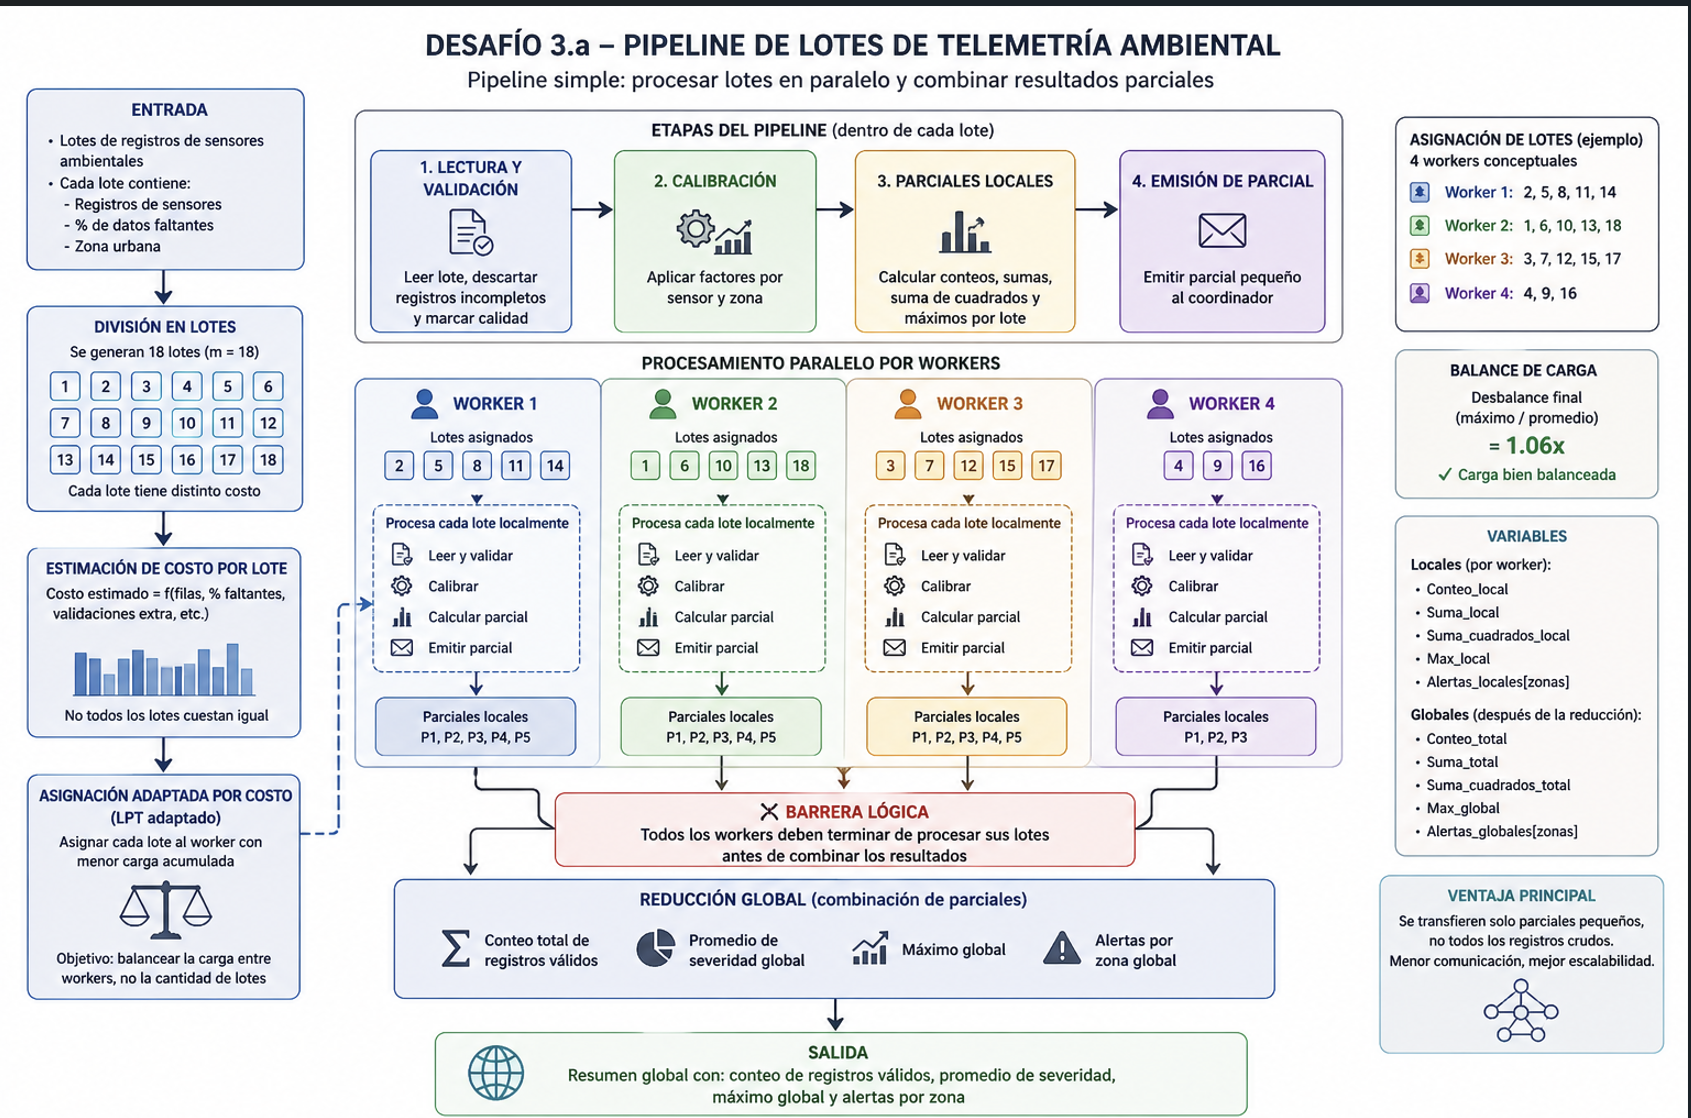

### 3.b - Justificacion tecnica final

La respuesta siguiente integra los criterios usados en todo el laboratorio y se mantiene dentro del rango pedido de 400 a 600 palabras.

In [11]:
final_justification = """
Para decidir como descomponer y particionar un problema nuevo, primero miraria la naturaleza del dato y la relacion entre cada entrada y cada salida. Si cada salida depende solo de una entrada o de un rango propio, como en la calibracion de sensores, conviene comenzar con una descomposicion por datos y un patron map. En ese caso la coordinacion es baja y el punto critico es asignar indices disjuntos para que ningun worker escriba dos veces la misma posicion. Si el resultado es un valor global, como promedio, varianza o maximo, entonces el patron ya no es solo map: aparece una reduccion. La decision correcta es calcular parciales locales y fusionarlos despues de una barrera logica, evitando acumuladores globales compartidos durante el trabajo paralelo.

El segundo criterio seria la regularidad de la carga. Si todos los datos cuestan parecido, una particion por bloques contiguos suele ser razonable porque mejora locality y reduce overhead de planificacion. Si el costo por dato o por lote es irregular, como en los sensores que requieren validacion extra o en los lotes con mas datos faltantes, una division uniforme puede dejar workers sobrecargados. En ese escenario compararia bloques, ciclico y asignacion adaptada por costo. La estrategia adaptada puede balancear mejor, pero tambien puede perder locality y agregar costo de planificacion; por eso no debe elegirse solo por intuicion.

El tercer criterio seria la presencia de dependencias. Cuando una posicion necesita vecinos, como en el indice de salto termico, una particion ingenua es incompleta. Antes de implementar hay que separar el rango que el worker escribe del rango que necesita leer. El halo permite mantener bloques paralelos sin romper la correctitud, pero aumenta comunicacion o transferencia de datos en las fronteras. Ese costo debe quedar explicitado en el pseudocodigo.

Tambien revisaria que informacion debe permanecer local y que informacion debe hacerse global. Esa separacion evita condiciones de carrera, escrituras repetidas y combinaciones prematuras. Un diseno claro debe indicar si el resultado final se arma por ensamblaje, por reduccion o por una etapa posterior del pipeline.

Finalmente revisaria granularidad, coordinacion y volumen de transferencia. Si las tareas son muy pequenas, el overhead puede dominar. Si se transfieren registros completos en lugar de parciales compactos, la comunicacion puede convertirse en el cuello de botella. Por eso, en el pipeline propuesto, cada worker procesa lotes completos localmente y solo emite estadisticas parciales para la reduccion final. Una buena estrategia paralela no promete acelerar todo; identifica que parte es local, que parte es global, donde hay barreras, que dependencias limitan el paralelismo y que riesgos aparecen si el balance de carga es debil.
""".strip()

word_count = len(final_justification.split())
assert 400 <= word_count <= 600

display(Markdown(final_justification))
metric_cards(
    [
        ("Extension", f"{word_count} palabras", "Dentro del rango solicitado", "#004E9A"),
        ("Criterios integrados", "7", "Datos, regularidad, granularidad, dependencias, reduccion, barreras y overhead", "#7AB830"),
        ("Decision central", "Disenar antes", "La herramienta viene despues del analisis estructural", "#113A5C"),
    ]
)

Para decidir como descomponer y particionar un problema nuevo, primero miraria la naturaleza del dato y la relacion entre cada entrada y cada salida. Si cada salida depende solo de una entrada o de un rango propio, como en la calibracion de sensores, conviene comenzar con una descomposicion por datos y un patron map. En ese caso la coordinacion es baja y el punto critico es asignar indices disjuntos para que ningun worker escriba dos veces la misma posicion. Si el resultado es un valor global, como promedio, varianza o maximo, entonces el patron ya no es solo map: aparece una reduccion. La decision correcta es calcular parciales locales y fusionarlos despues de una barrera logica, evitando acumuladores globales compartidos durante el trabajo paralelo.

El segundo criterio seria la regularidad de la carga. Si todos los datos cuestan parecido, una particion por bloques contiguos suele ser razonable porque mejora locality y reduce overhead de planificacion. Si el costo por dato o por lote es irregular, como en los sensores que requieren validacion extra o en los lotes con mas datos faltantes, una division uniforme puede dejar workers sobrecargados. En ese escenario compararia bloques, ciclico y asignacion adaptada por costo. La estrategia adaptada puede balancear mejor, pero tambien puede perder locality y agregar costo de planificacion; por eso no debe elegirse solo por intuicion.

El tercer criterio seria la presencia de dependencias. Cuando una posicion necesita vecinos, como en el indice de salto termico, una particion ingenua es incompleta. Antes de implementar hay que separar el rango que el worker escribe del rango que necesita leer. El halo permite mantener bloques paralelos sin romper la correctitud, pero aumenta comunicacion o transferencia de datos en las fronteras. Ese costo debe quedar explicitado en el pseudocodigo.

Tambien revisaria que informacion debe permanecer local y que informacion debe hacerse global. Esa separacion evita condiciones de carrera, escrituras repetidas y combinaciones prematuras. Un diseno claro debe indicar si el resultado final se arma por ensamblaje, por reduccion o por una etapa posterior del pipeline.

Finalmente revisaria granularidad, coordinacion y volumen de transferencia. Si las tareas son muy pequenas, el overhead puede dominar. Si se transfieren registros completos en lugar de parciales compactos, la comunicacion puede convertirse en el cuello de botella. Por eso, en el pipeline propuesto, cada worker procesa lotes completos localmente y solo emite estadisticas parciales para la reduccion final. Una buena estrategia paralela no promete acelerar todo; identifica que parte es local, que parte es global, donde hay barreras, que dependencias limitan el paralelismo y que riesgos aparecen si el balance de carga es debil.

## Conclusion final comparativa

La tabla siguiente resume los cuatro patrones trabajados en el laboratorio. Su objetivo es cerrar la entrega comparando que se divide, que se coordina y que riesgo tecnico domina en cada caso.

In [12]:
final_comparison_rows = [
    {
        "Patron o caso": "Map - calibracion de sensores",
        "Descomposicion": "Por datos",
        "Particionamiento recomendado": "Bloques contiguos si la carga es regular",
        "Coordinacion requerida": "Ensamblaje ordenado del vector final",
        "Riesgo principal": "Output-dependence si se repiten indices de salida",
        "Criterio de eleccion": "Usar cuando cada salida depende solo de su entrada local",
    },
    {
        "Patron o caso": "Reduction - resumen de alertas",
        "Descomposicion": "Por datos con parciales locales",
        "Particionamiento recomendado": "Chunks balanceados por cantidad o costo",
        "Coordinacion requerida": "Barrera logica y reduccion global",
        "Riesgo principal": "Acumuladores globales compartidos o combinacion incompleta",
        "Criterio de eleccion": "Usar cuando el resultado final agrega informacion de todo el arreglo",
    },
    {
        "Patron o caso": "Stencil/halo - salto termico",
        "Descomposicion": "Por bloques con lectura extendida",
        "Particionamiento recomendado": "Bloques con halo explicito en fronteras",
        "Coordinacion requerida": "Ensamblaje de rangos escritos sin duplicar bordes",
        "Riesgo principal": "Calcular mal o perder posiciones cercanas a fronteras",
        "Criterio de eleccion": "Usar cuando cada salida depende de vecinos locales",
    },
    {
        "Patron o caso": "Pipeline - telemetria por lotes",
        "Descomposicion": "Por tareas/lotes y etapas",
        "Particionamiento recomendado": "Asignacion adaptada por costo estimado",
        "Coordinacion requerida": "Transferencia de parciales y reduccion final",
        "Riesgo principal": "Desbalance por lotes irregulares o comunicacion excesiva",
        "Criterio de eleccion": "Usar cuando cada lote puede procesarse localmente por etapas",
    },
]
final_comparison_df = pd.DataFrame(final_comparison_rows)
show_df(final_comparison_df, "Comparacion final de patrones, coordinacion y riesgos")

display(
    Markdown(
        """
        ### Cierre comparativo

        Los cuatro casos muestran que el paralelismo disponible depende de la estructura del problema. En `map`, casi todo el
        trabajo es local y la coordinacion es minima. En `reduction`, el trabajo local puede ejecutarse en paralelo, pero el
        resultado global exige una barrera y una combinacion final. En el caso con halo, la independencia existe solo si cada
        worker recibe informacion de frontera suficiente. En el pipeline, la decision clave es procesar lotes completos localmente
        y transferir parciales pequenos. Por eso el diseno correcto no promete aceleracion sin analizar la estructura: explicita unidades de trabajo,
        dependencias, particionamiento, coordinacion y riesgos antes de implementar.
        """
    )
)

Patron o caso,Descomposicion,Particionamiento recomendado,Coordinacion requerida,Riesgo principal,Criterio de eleccion
Map - calibracion de sensores,Por datos,Bloques contiguos si la carga es regular,Ensamblaje ordenado del vector final,Output-dependence si se repiten indices de salida,Usar cuando cada salida depende solo de su entrada local
Reduction - resumen de alertas,Por datos con parciales locales,Chunks balanceados por cantidad o costo,Barrera logica y reduccion global,Acumuladores globales compartidos o combinacion incompleta,Usar cuando el resultado final agrega informacion de todo el arreglo
Stencil/halo - salto termico,Por bloques con lectura extendida,Bloques con halo explicito en fronteras,Ensamblaje de rangos escritos sin duplicar bordes,Calcular mal o perder posiciones cercanas a fronteras,Usar cuando cada salida depende de vecinos locales
Pipeline - telemetria por lotes,Por tareas/lotes y etapas,Asignacion adaptada por costo estimado,Transferencia de parciales y reduccion final,Desbalance por lotes irregulares o comunicacion excesiva,Usar cuando cada lote puede procesarse localmente por etapas



        ### Cierre comparativo

        Los cuatro casos muestran que el paralelismo disponible depende de la estructura del problema. En `map`, casi todo el
        trabajo es local y la coordinacion es minima. En `reduction`, el trabajo local puede ejecutarse en paralelo, pero el
        resultado global exige una barrera y una combinacion final. En el caso con halo, la independencia existe solo si cada
        worker recibe informacion de frontera suficiente. En el pipeline, la decision clave es procesar lotes completos localmente
        y transferir parciales pequenos. Por eso el diseno correcto no promete aceleracion sin analizar la estructura: explicita unidades de trabajo,
        dependencias, particionamiento, coordinacion y riesgos antes de implementar.
        

In [13]:
summary_payload = {
    "metadata": {
        "os": platform.platform(),
        "python": platform.python_version(),
        "logical_cpus": os.cpu_count(),
        "ram_gb": round(psutil.virtual_memory().total / 1024**3, 2) if psutil else None,
    },
    "challenge1": {
        "cases": ["Calibracion de sensores urbanos", "Resumen de alertas por cuadrante"],
        "best_partition": str(best_partition["Esquema"]),
        "best_partition_imbalance": float(best_partition["Desbalance max/prom"]),
        "block_imbalance": float(partition_metrics_df.loc[partition_metrics_df["Esquema"] == "Bloques contiguos", "Desbalance max/prom"].iloc[0]),
        "cyclic_imbalance": float(partition_metrics_df.loc[partition_metrics_df["Esquema"] == "Ciclico", "Desbalance max/prom"].iloc[0]),
        "adaptive_imbalance": float(partition_metrics_df.loc[partition_metrics_df["Esquema"] == "Adaptado por costo", "Desbalance max/prom"].iloc[0]),
    },
    "challenge2": {
        "reduction_workers": int(reduction_workers),
        "reduction_max_error": float(reduction_max_error),
        "stencil_workers": int(stencil_workers),
        "halo": int(halo),
        "stencil_max_error": float(stencil_max_error),
        "missing_naive": int(missing_naive),
    },
    "challenge3": {
        "batch_count": int(batch_count),
        "pipeline_workers": int(pipeline_workers),
        "pipeline_load_ratio": float(pipeline_load_ratio),
        "word_count": int(word_count),
    },
    "conclusion": {
        "patterns_compared": int(len(final_comparison_df)),
        "patterns": list(final_comparison_df["Patron o caso"]),
    },
}

with SUMMARY_PATH.open("w", encoding="utf-8") as summary_file:
    json.dump(summary_payload, summary_file, indent=2)

callout(
    "Verificacion final registrada",
    "El notebook queda ejecutado con las tablas, validaciones y conclusiones del laboratorio.",
    accent="#004E9A",
    bg="#F5F9FE",
)